# Vegetation recovery metrics

*SPDX-FileCopyrightText: © 2026 Nina Preußler <nina.preussler@studserv.uni-leipzig.de>*

*SPDX-License-Identifier: CC BY 4.0*

To quantify vegetation recovery, we used the relative vegetation recovery rate - used under different names and slightly different different equations (but same expressed value) in literature on vegetation recovery after disturbance, e.g. fire (https://www.sciencedirect.com/science/article/pii/S0924271620301039) and earthquakes (https://www.mdpi.com/2072-4292/7/7/8757).

- used EVI due to high vegetation density (better than NDVI)
- using MODIS MOD13Q1 EVI
- short- and mid-term recovery rate (after two and five years, 2017 and 2020)

In [2]:
import xarray as xr
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# import study area
study_area = rxr.open_rasterio('output-data/study-area/study_area.tif').squeeze()                           

In [4]:
# set up merged data array that combines all layers
from rasterio.enums import Resampling

merged_evis = study_area.rename('study_area')

for layer in ['pre', 'post', '2017', '2020']:

    # load raster
    array = rxr.open_rasterio(f'input-data/MODIS-exports/EVI_{layer}.tif')

    # split into bands
    band_evi = array.sel(band=1)
    band_qa = array.sel(band=2)

    # but since all images are multi-month to multi-year composites (median), outliers and 
    # poor quality values are mostly smoothed out

    # apply scale factors (values originally stored as integers)
    band_evi_scaled = band_evi * 0.0001

    # quality control: EVI can only be between -1 and 1
    band_evi_scaled = xr.where(
        (band_evi_scaled >= -1) & (band_evi_scaled <= 1), 
        band_evi_scaled, # if True
        np.nan) # if False

    # reproject to ensure alignment
    band_evi_reproj = band_evi_scaled.rio.reproject_match(
        study_area, 
        resampling=Resampling.bilinear)

    # mask with study area
    band_evi_reproj = xr.where(
        study_area == 1,
        band_evi_reproj, # if True, keep value
        np.nan) # if False
        
    # merge 
    merged_evis = xr.merge([merged_evis, 
                            band_evi_reproj.rename(f'evi_{layer}')], 
                           compat='no_conflicts')

In [5]:
merged_evis

<xarray.Dataset> Size: 596MB
Dimensions:      (x: 4721, y: 3825)
Coordinates:
  * x            (x) float64 38kB 108.5 108.5 108.5 108.5 ... 119.1 119.1 119.1
  * y            (y) float64 31kB 4.369 4.367 4.365 ... -4.214 -4.216 -4.219
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    study_area   (y, x) uint8 18MB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    evi_pre      (y, x) float64 144MB nan nan nan nan nan ... nan nan nan nan
    evi_post     (y, x) float64 144MB nan nan nan nan nan ... nan nan nan nan
    evi_2017     (y, x) float64 144MB nan nan nan nan nan ... nan nan nan nan
    evi_2020     (y, x) float64 144MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1
    STATISTICS_MEAN:           0.0010254755012222
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         0.03200662277121
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 study_area

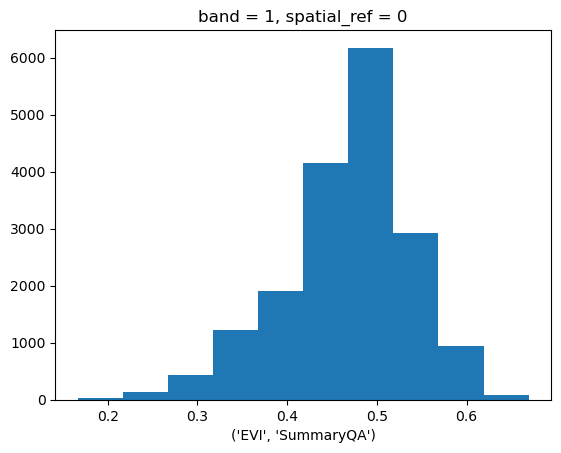

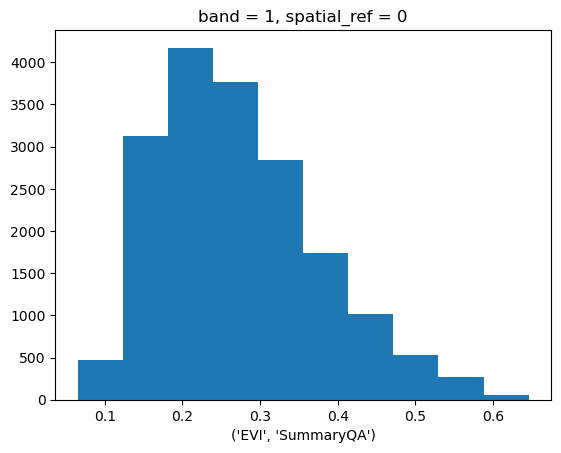

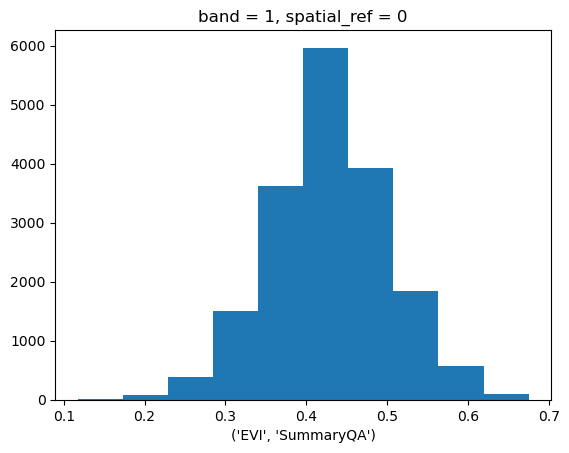

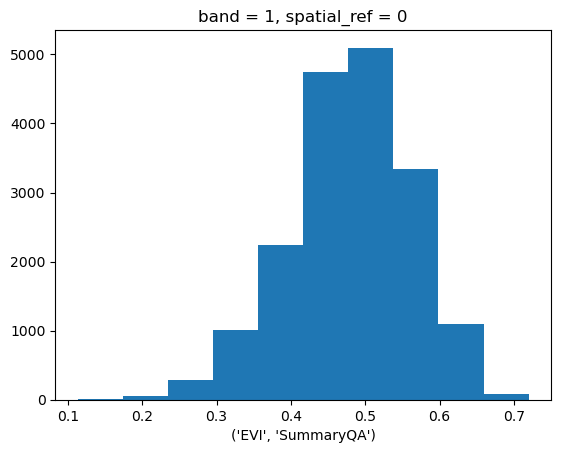

In [6]:
# plot histograms
merged_evis.evi_pre.plot.hist()
plt.show()
merged_evis.evi_post.plot.hist()
plt.show()
merged_evis.evi_2017.plot.hist()
plt.show()
merged_evis.evi_2020.plot.hist()
plt.show()

In [7]:
# compute recovery metrics
for year in ['2017', '2020']:
    merged_evis[f'recovery_rate_{year}'] = (merged_evis[f'evi_{year}'] - merged_evis.evi_post) / (merged_evis.evi_pre - merged_evis.evi_post) * 100

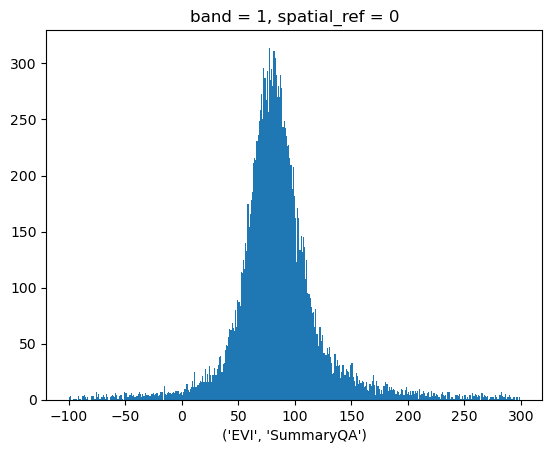

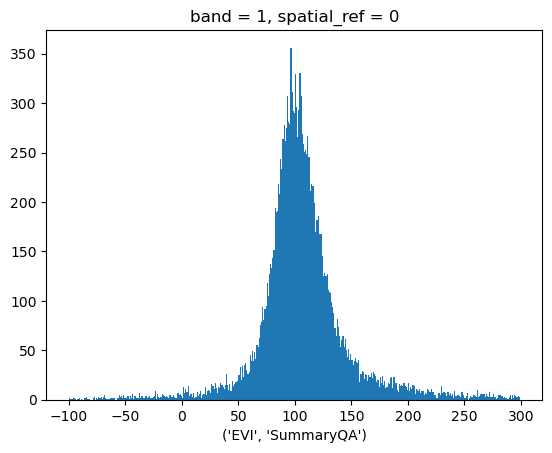

In [10]:
# plot distribution
merged_evis.recovery_rate_2017.plot.hist(bins=np.arange(-100,300,1))
plt.show()

merged_evis.recovery_rate_2020.plot.hist(bins=np.arange(-100,300,1))
plt.show()

In [16]:
# make sure to exclude outliers
merged_evis['recovery_rate_2017'] = xr.where(
    (merged_evis.recovery_rate_2017 < -100) | (merged_evis.recovery_rate_2017 > 300),
    np.nan, merged_evis.recovery_rate_2017).rio.write_crs(4326)
merged_evis['recovery_rate_2020'] = xr.where(
    (merged_evis.recovery_rate_2020 < -100) | (merged_evis.recovery_rate_2020 > 300),
    np.nan, merged_evis.recovery_rate_2020).rio.write_crs(4326)

In [19]:
# remove attribute that prevents export
# del merged_evis.recovery_rate_2017.attrs['long_name']
# del merged_evis.recovery_rate_2020.attrs['long_name']
del merged_evis.evi_pre.attrs['long_name']

In [20]:
# export
merged_evis.recovery_rate_2017.rio.to_raster('output-data/target-variables/recovery_rate_2017.tif')
merged_evis.recovery_rate_2020.rio.to_raster('output-data/target-variables/recovery_rate_2020.tif')

merged_evis.evi_pre.rio.to_raster('output-data/predictor-layers/evi_pre.tif')

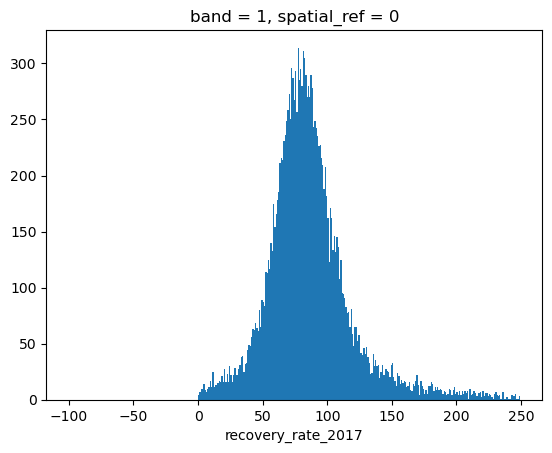

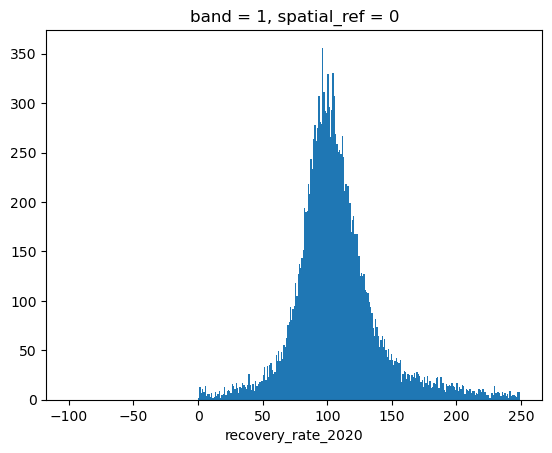

In [21]:
# make one copy where negative vegetation recovery is masked out

recovery_rate_2017_no_neg = xr.where(
    merged_evis.recovery_rate_2017 > 0,
    merged_evis.recovery_rate_2017,
    np.nan).rio.write_crs(4326)

recovery_rate_2017_no_neg.plot.hist(bins=np.arange(-100,250,1))
plt.show()

recovery_rate_2020_no_neg = xr.where(
    merged_evis.recovery_rate_2020 > 0,
    merged_evis.recovery_rate_2020,
    np.nan).rio.write_crs(4326)
                                               
recovery_rate_2020_no_neg.plot.hist(bins=np.arange(-100,250,1))
plt.show()                                            

In [22]:
# export 
recovery_rate_2017_no_neg.rio.to_raster('output-data/target-variables/recovery_rate_2017_no_neg.tif')
recovery_rate_2020_no_neg.rio.to_raster('output-data/target-variables/recovery_rate_2020_no_neg.tif')